In [1]:
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt

np.bool8 = np.bool_


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Noisy Networks

### Main Ideas:

1. **Enhancing Exploration with Parameter Noise**:
   - Traditional exploration strategies in reinforcement learning, such as ε-greedy, involve adding randomness to action selection.
   - **Noisy Networks (Noisy Nets)** introduce stochasticity directly into the network parameters, enabling more sophisticated and efficient exploration by incorporating parameter noise into the action-value function.

2. **Parameter-Based Exploration**:
   - Instead of perturbing actions or rewards, Noisy Nets add noise to the network weights, allowing the agent to explore by varying its policy in a more structured manner.
   - This approach can lead to more consistent exploration patterns and improved sample efficiency.

3. **Learnable Noise Parameters**:
   - Noisy Nets incorporate learnable parameters for noise, allowing the network to adjust the level of stochasticity based on the learning process.
   - This adaptability enables the agent to reduce exploration as it becomes more confident in its policy, leading to a natural annealing of exploration over time.

4. **Integration with Other Rainbow Components**:
   - **Noisy Networks** synergize with other Rainbow DQN components, such as **Dueling Networks**, **Prioritized Experience Replay**, and **Double DQN**, to enhance overall learning efficiency and performance.
   - When combined, these techniques provide a more comprehensive approach to tackling complex reinforcement learning tasks.

### Structure of Noisy Networks:

- **Noisy Linear Layers**:
  - Traditional linear layers in neural networks are augmented with noise, typically using factorized Gaussian noise.
  - Each weight in the noisy linear layer is represented as:
    $$
    y = (b + W x) + (b_{\text{noisy}} + W_{\text{noisy}} x)
    $$
    where:
    - $ b $ and $ W $ are the deterministic bias and weight parameters.
    - $ b_{\text{noisy}} $ and $ W_{\text{noisy}} $ are the noisy bias and weight parameters.
    - The noisy parameters are defined as:
      $$
      W_{\text{noisy}} = \sigma_W \odot \epsilon_{\text{out}} \epsilon_{\text{in}}^T
      $$
      $$
      b_{\text{noisy}} = \sigma_b \odot \epsilon_{\text{out}}
      $$
      where:
      - $ \sigma_W $ and $ \sigma_b $ are learnable standard deviation parameters.
      - $ \epsilon_{\text{in}} $ and $ \epsilon_{\text{out}} $ are noise vectors sampled from a standard normal distribution.
      - $ \odot $ denotes element-wise multiplication.
      - $ \epsilon_{\text{out}} \epsilon_{\text{in}}^T $ represents the outer product, ensuring that noise is factorized across input and output dimensions.

- **Factorized Gaussian Noise**:
  - To efficiently generate noise for all weights, Noisy Nets use factorized Gaussian noise.
  - This involves generating separate noise vectors for the input $ \epsilon_{\text{in}} $ and output $ \epsilon_{\text{out}} $ dimensions and combining them to produce the noise for each weight.
  - The noise variables are transformed using a function $ f $ (often $ f(x) = \text{sign}(x) \sqrt{|x|} $) to ensure zero mean and unit variance, maintaining the stability of the network.

- **Learnable Noise Parameters**:
  - The parameters $ \mu_W $, $ \sigma_W $, $ \mu_b $, and $ \sigma_b $ are learned alongside the rest of the network parameters.
  - This allows the network to adapt the level of noise based on the learning dynamics, facilitating controlled exploration.

### Why Noisy Networks?

1. **Efficient and Adaptive Exploration**:
   - Noisy Nets provide a more efficient exploration strategy by injecting noise directly into the network parameters, allowing for richer and more consistent exploration patterns compared to simple action perturbations.

2. **Reduced Need for External Exploration Strategies**:
   - By incorporating noise into the network itself, the reliance on external exploration mechanisms like ε-greedy is reduced, simplifying the overall architecture.

3. **Learnable Exploration Rate**:
   - The exploration level is not fixed but learned, allowing the agent to automatically adjust the degree of exploration based on its confidence in the policy, leading to a natural annealing process.

4. **Improved Sample Efficiency**:
   - By enabling more effective exploration, Noisy Nets can lead to faster learning and better performance with fewer training samples.

### Advantages of Noisy Networks

1. **Improved Exploration Efficiency**:
   - Provides a structured and efficient way to explore the action space, potentially discovering better policies more quickly than random action perturbations.

2. **Adaptive Noise Levels**:
   - The network learns to adjust the noise levels, reducing exploration as the agent becomes more certain about the optimal policy, which can enhance convergence rates.

3. **Simplified Exploration Mechanism**:
   - Eliminates the need for manually tuning exploration parameters like ε in ε-greedy strategies, as the noise levels are learned automatically.

4. **Enhanced Performance in Complex Environments**:
   - Particularly beneficial in environments with large or continuous action spaces, where traditional exploration methods may struggle.

In [3]:
# --- Noisy Linear Layer ---
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, sigma_0=0.5):
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.sigma_0 = sigma_0

        # Mean and sigma weights
        self.w_mu = nn.Parameter(torch.empty(in_features, out_features))
        self.w_sigma = nn.Parameter(torch.empty(in_features, out_features))
        self.b_mu = nn.Parameter(torch.empty(out_features))
        self.b_sigma = nn.Parameter(torch.empty(out_features))

        self.reset_parameters()

    def reset_parameters(self):
        mu_range = 1 / np.sqrt(self.in_features)
        self.w_mu.data.uniform_(-mu_range, mu_range)
        self.b_mu.data.uniform_(-mu_range, mu_range)
        self.w_sigma.data.fill_(self.sigma_0 / np.sqrt(self.in_features))
        self.b_sigma.data.fill_(self.sigma_0 / np.sqrt(self.in_features))

    def forward(self, x):
        if self.training:
            epsilon_in = self._f(torch.randn(self.in_features, 1, device=device))
            epsilon_out = self._f(torch.randn(1, self.out_features, device=device))
            w_noise = torch.matmul(epsilon_in, epsilon_out)
            b_noise = epsilon_out.squeeze()
        else:
            w_noise = torch.zeros_like(self.w_sigma)
            b_noise = torch.zeros_like(self.b_sigma)

        w = self.w_mu + self.w_sigma * w_noise
        b = self.b_mu + self.b_sigma * b_noise
        return torch.matmul(x, w) + b

    def _f(self, x):
        return torch.sign(x) * torch.sqrt(torch.abs(x) + 1e-10)

In [4]:
# --- NoisyNet Q-Network ---
class NoisyQNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NoisyQNetwork, self).__init__()
        self.net = nn.Sequential(
            NoisyLinear(input_dim, 128),
            nn.ReLU(),
            NoisyLinear(128, 128),
            nn.ReLU(),
            NoisyLinear(128, 128),
            nn.ReLU(),
            NoisyLinear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
# --- DQN Agent with NoisyNet ---
class NoisyDQNAgent:
    def __init__(self, obs_dim, n_actions, gamma=0.99, lr=1e-3, buffer_size=50000):
        self.gamma = gamma
        self.n_actions = n_actions

        self.model = NoisyQNetwork(obs_dim, n_actions).to(device)
        self.target_model = NoisyQNetwork(obs_dim, n_actions).to(device)
        self.target_model.load_state_dict(self.model.state_dict())

        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.buffer = deque(maxlen=buffer_size)

    def remember(self, s, a, r, s_, done):
        self.buffer.append((s, a, r, s_, done))

    def act(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return int(q_values.argmax(dim=1).item())

    def train(self, batch_size=32):
        if len(self.buffer) < batch_size:
            return

        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_, d = zip(*batch)

        s = torch.FloatTensor(s).to(device)
        a = torch.LongTensor(a).unsqueeze(1).to(device)
        r = torch.FloatTensor(r).unsqueeze(1).to(device)
        s_ = torch.FloatTensor(s_).to(device)
        d = torch.FloatTensor(d).unsqueeze(1).to(device)

        q_vals = self.model(s).gather(1, a)

        with torch.no_grad():
            next_q_vals = self.target_model(s_).max(1)[0].unsqueeze(1)
            target = r + self.gamma * next_q_vals * (1 - d)

        loss = self.loss_fn(q_vals, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

C:\Users\admin\AppData\Local\Temp\ipykernel_21740\1923460351.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  s = torch.FloatTensor(s).to(device)


Ep 0 | Score: -234.2 | Avg50: -234.2
Ep 1 | Score: -280.7 | Avg50: -257.4
Ep 2 | Score: -272.2 | Avg50: -262.3
Ep 3 | Score: -369.8 | Avg50: -289.2
Ep 4 | Score: -355.9 | Avg50: -302.5
Ep 5 | Score: -160.3 | Avg50: -278.8
Ep 6 | Score: -156.5 | Avg50: -261.4
Ep 7 | Score: -303.2 | Avg50: -266.6
Ep 8 | Score: -156.1 | Avg50: -254.3
Ep 9 | Score: -246.1 | Avg50: -253.5
Ep 10 | Score: -146.1 | Avg50: -243.7
Ep 11 | Score: -124.5 | Avg50: -233.8
Ep 12 | Score: -291.6 | Avg50: -238.2
Ep 13 | Score: -119.7 | Avg50: -229.8
Ep 14 | Score: -381.3 | Avg50: -239.9
Ep 15 | Score: -189.2 | Avg50: -236.7
Ep 16 | Score: -96.8 | Avg50: -228.5
Ep 17 | Score: -164.3 | Avg50: -224.9
Ep 18 | Score: -243.7 | Avg50: -225.9
Ep 19 | Score: -176.0 | Avg50: -223.4
Ep 20 | Score: -116.4 | Avg50: -218.3
Ep 21 | Score: -353.3 | Avg50: -224.4
Ep 22 | Score: -118.4 | Avg50: -219.8
Ep 23 | Score: -114.3 | Avg50: -215.4
Ep 24 | Score: -330.0 | Avg50: -220.0
Ep 25 | Score: -226.5 | Avg50: -220.3
Ep 26 | Score: -262.8 |

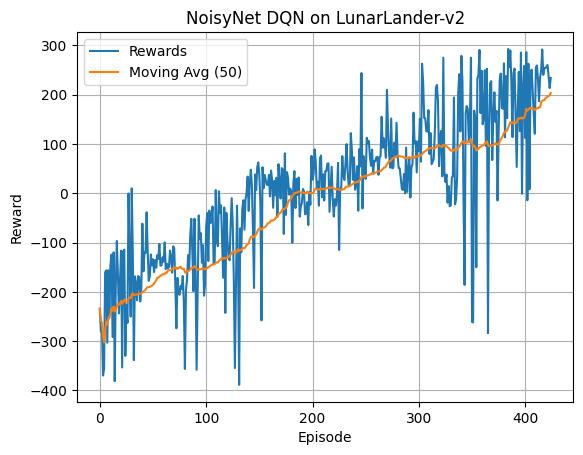

: 

In [ ]:
env = gym.make("LunarLander-v2")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
agent = NoisyDQNAgent(obs_dim, n_actions)

episodes = 2000
max_steps = 500
target_update_freq = 400
time_step = 0

rewards = []
avgs = []

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for t in range(max_steps):
        time_step += 1
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)
        agent.train()

        state = next_state
        total_reward += reward

        if time_step % target_update_freq == 0:
            agent.update_target()

        if done:
            break

    rewards.append(total_reward)
    avg = np.mean(rewards[-50:])
    avgs.append(avg)
    print(f"Ep {ep} | Score: {total_reward:.1f} | Avg50: {avg:.1f}")

    if avg >= 200:
        print("Environment solved!")
        break

plt.plot(rewards, label="Rewards")
plt.plot(avgs, label="Moving Avg (50)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("NoisyNet DQN on LunarLander-v2")
plt.legend()
plt.grid()
plt.show()